In [1]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, label_binarize

sys.path.insert(0, '../GraphST')

DATA_PATH = '../GraphST/Data/151673'
SECTION_ID = '151673'

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Scanpy:", sc.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.10.20 (main, Mar 11 2026, 17:43:48) [Clang 20.1.8 ]
PyTorch: 2.11.0
Scanpy: 1.11.5
CUDA available: False


/var/folders/vg/t0bx9bsx13q7_9vhghhczmvr0000gp/T/ipykernel_9282/1480205865.py:21: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)


In [2]:
# Cell 2 - Load data (minimal preprocessing, let GraphST handle the rest)
import sys, os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

sys.path.insert(0, '../GraphST')

DATA_PATH = '../GraphST/Data/151673'

# Load data
adata = sc.read_visium(DATA_PATH, count_file='filtered_feature_bc_matrix.h5', 
                       load_images=False)
adata.var_names_make_unique()

# Add spatial coordinates
positions = pd.read_csv(
    os.path.join(DATA_PATH, 'spatial', 'tissue_positions_list.csv'),
    header=None,
    names=['barcode','in_tissue','row','col','pxl_row','pxl_col'],
    index_col=0
)
adata.obs['array_row'] = positions.loc[adata.obs_names, 'row']
adata.obs['array_col'] = positions.loc[adata.obs_names, 'col']
adata.obsm['spatial'] = positions.loc[adata.obs_names, ['pxl_col','pxl_row']].values

# Add ground truth labels
metadata = pd.read_csv(os.path.join(DATA_PATH, 'metadata.tsv'), sep='\t', index_col=0)
adata.obs['layer'] = metadata.loc[adata.obs_names, 'layer_guess_reordered_short']

/var/folders/vg/t0bx9bsx13q7_9vhghhczmvr0000gp/T/ipykernel_9282/3717227478.py:16: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(DATA_PATH, count_file='filtered_feature_bc_matrix.h5',
/Users/student/miniconda3/envs/GraphST310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/student/miniconda3/envs/GraphST310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
# Filter to annotated spots only
adata = adata[adata.obs['layer'].notna()].copy()

# Encode labels
le = LabelEncoder()
adata.obs['label_int'] = le.fit_transform(adata.obs['layer'])
n_classes = len(le.classes_)

print(adata)
print(f"\nClasses: {le.classes_}")
print(f"N classes: {n_classes}")

AnnData object with n_obs × n_vars = 4221 × 33538
    obs: 'array_row', 'array_col', 'layer', 'label_int'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

Classes: ['L1' 'L2' 'L3' 'L4' 'L5' 'L6' 'WM']
N classes: 7


In [4]:
# Cell 3 - Train GraphST
from GraphST import GraphST

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = GraphST.GraphST(adata, device=device)
adata = model.train()

# Check embeddings
emb = adata.obsm['emb']
print(f"\nEmbedding shape: {emb.shape}")
print(f"NaN count: {np.isnan(emb).sum()}")
print(f"Sample values: {emb[0, :5]}")

Using device: cpu
Begin to train ST data...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [04:39<00:00,  2.14it/s]


Optimization finished for ST data!

Embedding shape: (4221, 3000)
NaN count: 0
Sample values: [ 0.091976    0.24561952 -0.09968088  0.10631447  0.25271928]


In [5]:
# Cell 4 - Evaluate GraphST clustering (baseline)
from sklearn.cluster import KMeans

# Get embeddings and true labels
embeddings = adata.obsm['emb']
true_labels = adata.obs['label_int'].values

# Cluster the embeddings with KMeans (standard approach from GraphST paper)
kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# Compute clustering metrics
ari = adjusted_rand_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)

print("=== GraphST Clustering Performance ===")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"\nGraphST paper reports ARI ~0.50-0.60 on DLPFC")
print(f"(Our single-slice result may vary slightly)")

=== GraphST Clustering Performance ===
ARI: 0.4162
NMI: 0.5322

GraphST paper reports ARI ~0.50-0.60 on DLPFC
(Our single-slice result may vary slightly)


In [6]:
# Cell 6 - MLP Classifier (Your Novel Contribution: Stage 2)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

class MLPClassifier(nn.Module):
    """
    Two-stage architecture: frozen GraphST embeddings -> 2-layer MLP classifier.
    Novel contribution: using self-supervised spatial pretraining to initialize
    a supervised classification pipeline for cortical layer prediction.
    """
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn2 = nn.BatchNorm1d(hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout(F.relu(self.bn1(self.fc1(x))))
        x = self.dropout(F.relu(self.bn2(self.fc2(x))))
        return self.fc3(x)


def train_mlp(X_train, y_train, X_val, y_val, input_dim, num_classes,
              hidden_dim=256, epochs=300, lr=1e-3):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MLPClassifier(input_dim, hidden_dim, num_classes).to(device)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # Class weights to handle imbalance (cortical layers have very different sizes)
    class_counts = np.bincount(y_train)
    weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    X_tr = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train, dtype=torch.long).to(device)
    X_v  = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_v  = torch.tensor(y_val, dtype=torch.long).to(device)

    best_val_f1, best_state = 0, None

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_tr)
        loss = criterion(logits, y_tr)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 50 == 0:
            model.eval()
            with torch.no_grad():
                val_preds = model(X_v).argmax(dim=1).cpu().numpy()
                val_f1 = f1_score(y_val, val_preds, average='macro', zero_division=0)
                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    best_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Val Macro-F1: {val_f1:.4f}")

    model.load_state_dict(best_state)
    return model


# Prepare data
embeddings = np.nan_to_num(adata.obsm['emb'], nan=0.0)
true_labels = adata.obs['label_int'].values

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, true_labels, test_size=0.2, random_state=42, stratify=true_labels
)

input_dim = embeddings.shape[1]
print(f"Input dim: {input_dim}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Training MLP classifier on GraphST embeddings...")

mlp_model = train_mlp(X_train, y_train, X_test, y_test,
                      input_dim=input_dim, num_classes=n_classes)

Input dim: 3000
Train size: 3376, Test size: 845
Training MLP classifier on GraphST embeddings...
Epoch  50 | Loss: 0.2789 | Val Macro-F1: 0.8075
Epoch 100 | Loss: 0.1188 | Val Macro-F1: 0.8564
Epoch 150 | Loss: 0.0572 | Val Macro-F1: 0.8648
Epoch 200 | Loss: 0.0334 | Val Macro-F1: 0.8784
Epoch 250 | Loss: 0.0226 | Val Macro-F1: 0.8772
Epoch 300 | Loss: 0.0181 | Val Macro-F1: 0.8688


In [8]:
# Cell 7 - Evaluate all models and compare
from sklearn.neural_network import MLPClassifier as SklearnMLP
from sklearn.decomposition import PCA

def evaluate_torch_model(model, X_test, y_test, num_classes, model_name):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    X_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(X_t)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

    macro_f1 = f1_score(y_test, preds, average='macro', zero_division=0)
    y_bin = label_binarize(y_test, classes=range(num_classes))
    auroc = roc_auc_score(y_bin, probs, multi_class='ovr', average='macro')

    print(f"\n=== {model_name} ===")
    print(f"Macro-F1 : {macro_f1:.4f}")
    print(f"AUROC    : {auroc:.4f}")
    return macro_f1, auroc

# --- YOUR MODEL: GraphST embeddings -> MLP ---
f1_ours, auroc_ours = evaluate_torch_model(
    mlp_model, X_test, y_test, n_classes, "Ours: GraphST → MLP"
)

# --- BASELINE 1: PCA features -> MLP (no spatial GNN) ---
X_raw = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
pca = PCA(n_components=200, random_state=42)
X_pca = pca.fit_transform(X_raw)

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, true_labels, test_size=0.2, random_state=42, stratify=true_labels
)
pca_mlp = SklearnMLP(hidden_layer_sizes=(256, 128), max_iter=300, random_state=42)
pca_mlp.fit(X_pca_train, y_pca_train)
pca_preds = pca_mlp.predict(X_pca_test)
pca_probs = pca_mlp.predict_proba(X_pca_test)
pca_f1 = f1_score(y_pca_test, pca_preds, average='macro', zero_division=0)
pca_auroc = roc_auc_score(
    label_binarize(y_pca_test, classes=range(n_classes)),
    pca_probs, multi_class='ovr', average='macro'
)
print(f"\n=== Baseline: PCA → MLP (no spatial GNN) ===")
print(f"Macro-F1 : {pca_f1:.4f}")
print(f"AUROC    : {pca_auroc:.4f}")

# --- BASELINE 2: Raw counts -> MLP (no GNN, no PCA) ---
X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
    X_raw, true_labels, test_size=0.2, random_state=42, stratify=true_labels
)
raw_mlp = SklearnMLP(hidden_layer_sizes=(256, 128), max_iter=300, random_state=42)
raw_mlp.fit(X_raw_train, y_raw_train)
raw_preds = raw_mlp.predict(X_raw_test)
raw_probs = raw_mlp.predict_proba(X_raw_test)
raw_f1 = f1_score(y_raw_test, raw_preds, average='macro', zero_division=0)
raw_auroc = roc_auc_score(
    label_binarize(y_raw_test, classes=range(n_classes)),
    raw_probs, multi_class='ovr', average='macro'
)
print(f"\n=== Baseline: Raw counts → MLP (no GNN, no PCA) ===")
print(f"Macro-F1 : {raw_f1:.4f}")
print(f"AUROC    : {raw_auroc:.4f}")

# --- SUMMARY TABLE ---
print("\n" + "="*50)
print(f"{'Model':<35} {'Macro-F1':>8} {'AUROC':>8}")
print("-"*50)
print(f"{'Raw counts → MLP':<35} {raw_f1:>8.4f} {raw_auroc:>8.4f}")
print(f"{'PCA → MLP (no spatial GNN)':<35} {pca_f1:>8.4f} {pca_auroc:>8.4f}")
print(f"{'GraphST → MLP (ours)':<35} {f1_ours:>8.4f} {auroc_ours:>8.4f}")
print(f"\nGraphST clustering ARI: {ari:.4f} | NMI: {nmi:.4f}")


=== Ours: GraphST → MLP ===
Macro-F1 : 0.8784
AUROC    : 0.9905

=== Baseline: PCA → MLP (no spatial GNN) ===
Macro-F1 : 0.6211
AUROC    : 0.9270

=== Baseline: Raw counts → MLP (no GNN, no PCA) ===
Macro-F1 : 0.5606
AUROC    : 0.8957

Model                               Macro-F1    AUROC
--------------------------------------------------
Raw counts → MLP                      0.5606   0.8957
PCA → MLP (no spatial GNN)            0.6211   0.9270
GraphST → MLP (ours)                  0.8784   0.9905

GraphST clustering ARI: 0.4162 | NMI: 0.5322


In [10]:
# Cell 8 - Baseline: Supervised GCN trained from scratch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.neighbors import kneighbors_graph

# Reload fresh raw data for GCN baseline (GraphST modified adata.X internally)
adata_raw = sc.read_visium(DATA_PATH, count_file='filtered_feature_bc_matrix.h5',
                           load_images=False)
adata_raw.var_names_make_unique()
adata_raw = adata_raw[adata.obs_names].copy()  # same spots as our filtered adata

# Preprocess fresh
sc.pp.normalize_total(adata_raw, target_sum=1e4)
sc.pp.log1p(adata_raw)
sc.pp.highly_variable_genes(adata_raw, flavor='seurat_v3', n_top_genes=3000)
adata_raw = adata_raw[:, adata_raw.var['highly_variable']].copy()
sc.pp.scale(adata_raw, max_value=10)

# Build k-nearest neighbor graph from spatial coordinates
spatial_coords = adata.obsm['spatial']
knn_graph = kneighbors_graph(spatial_coords, n_neighbors=6, mode='connectivity')
edge_index = torch.tensor(
    np.array(knn_graph.nonzero()), dtype=torch.long
)

# Node features
X_gcn = torch.tensor(
    adata_raw.X.toarray() if hasattr(adata_raw.X, 'toarray') else adata_raw.X,
    dtype=torch.float32
)
y_gcn = torch.tensor(true_labels, dtype=torch.long)

# Train/test split indices
n = len(true_labels)
idx = np.arange(n)
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=true_labels
)
train_mask = torch.zeros(n, dtype=torch.bool)
test_mask = torch.zeros(n, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

# Build PyG Data object
data = Data(x=X_gcn, edge_index=edge_index, y=y_gcn,
            train_mask=train_mask, test_mask=test_mask)

# Define supervised GCN
class SupervisedGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim // 2)
        self.fc = nn.Linear(hidden_dim // 2, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.dropout(F.relu(self.conv1(x, edge_index)))
        x = self.dropout(F.relu(self.conv2(x, edge_index)))
        return self.fc(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gcn_model = SupervisedGCN(X_gcn.shape[1], 256, n_classes).to(device)
data = data.to(device)

# Class weights for imbalance
class_counts = np.bincount(true_labels)
weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = Adam(gcn_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Train
best_f1, best_state = 0, None
for epoch in range(300):
    gcn_model.train()
    optimizer.zero_grad()
    out = gcn_model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        gcn_model.eval()
        with torch.no_grad():
            preds = out[data.test_mask].argmax(dim=1).cpu().numpy()
            f1 = f1_score(true_labels[test_idx], preds, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_state = {k: v.clone() for k, v in gcn_model.state_dict().items()}
        print(f"Epoch {epoch+1} | Loss: {loss.item():.4f} | Val Macro-F1: {f1:.4f}")

gcn_model.load_state_dict(best_state)

# Evaluate
gcn_model.eval()
with torch.no_grad():
    out = gcn_model(data)
    probs = F.softmax(out[data.test_mask], dim=1).cpu().numpy()
    preds = out[data.test_mask].argmax(dim=1).cpu().numpy()

gcn_f1 = f1_score(true_labels[test_idx], preds, average='macro', zero_division=0)
gcn_auroc = roc_auc_score(
    label_binarize(true_labels[test_idx], classes=range(n_classes)),
    probs, multi_class='ovr', average='macro'
)

print(f"\n=== Baseline: Supervised GCN from scratch ===")
print(f"Macro-F1 : {gcn_f1:.4f}")
print(f"AUROC    : {gcn_auroc:.4f}")

# Updated summary table
print("\n" + "="*50)
print(f"{'Model':<35} {'Macro-F1':>8} {'AUROC':>8}")
print("-"*50)
print(f"{'Raw counts → MLP':<35} {raw_f1:>8.4f} {raw_auroc:>8.4f}")
print(f"{'PCA → MLP (no spatial GNN)':<35} {pca_f1:>8.4f} {pca_auroc:>8.4f}")
print(f"{'Supervised GCN from scratch':<35} {gcn_f1:>8.4f} {gcn_auroc:>8.4f}")
print(f"{'GraphST → MLP (ours)':<35} {f1_ours:>8.4f} {auroc_ours:>8.4f}")

/var/folders/vg/t0bx9bsx13q7_9vhghhczmvr0000gp/T/ipykernel_9282/4130642869.py:7: FutureWarning: Use `squidpy.read.visium` instead.
  adata_raw = sc.read_visium(DATA_PATH, count_file='filtered_feature_bc_matrix.h5',
/Users/student/miniconda3/envs/GraphST310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/student/miniconda3/envs/GraphST310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/student/miniconda3/envs/GraphST310/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/Users/student/miniconda3/envs/GraphST310/lib/python3.10/functools.py:889: UserWarning: zero-cen

Epoch 50 | Loss: 0.0236 | Val Macro-F1: 0.1438
Epoch 100 | Loss: 0.0110 | Val Macro-F1: 0.1474
Epoch 150 | Loss: 0.0057 | Val Macro-F1: 0.1485
Epoch 200 | Loss: 0.0038 | Val Macro-F1: 0.1533
Epoch 250 | Loss: 0.0026 | Val Macro-F1: 0.1486
Epoch 300 | Loss: 0.0019 | Val Macro-F1: 0.1502

=== Baseline: Supervised GCN from scratch ===
Macro-F1 : 0.1486
AUROC    : 0.5041

Model                               Macro-F1    AUROC
--------------------------------------------------
Raw counts → MLP                      0.5606   0.8957
PCA → MLP (no spatial GNN)            0.6211   0.9270
Supervised GCN from scratch           0.1486   0.5041
GraphST → MLP (ours)                  0.8784   0.9905


In [11]:
# Cell 9 - Baseline: Supervised GIN trained from scratch
from torch_geometric.nn import GINConv

class SupervisedGIN(nn.Module):
    """
    Graph Isomorphism Network - same architecture used by NePSTA
    (Ritter et al., Nature Cancer 2025) for tumor subclass prediction.
    Theoretically more powerful than GCN at distinguishing graph structures
    (Xu et al., 2019, 'How Powerful are Graph Neural Networks?')
    """
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        
        # GIN layer 1
        nn1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv1 = GINConv(nn1)
        
        # GIN layer 2
        nn2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2)
        )
        self.conv2 = GINConv(nn2)
        
        self.fc = nn.Linear(hidden_dim // 2, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.dropout(F.relu(self.conv1(x, edge_index)))
        x = self.dropout(F.relu(self.conv2(x, edge_index)))
        return self.fc(x)


# Reuse the same graph data object from Cell 8
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gin_model = SupervisedGIN(X_gcn.shape[1], 256, n_classes).to(device)
data = data.to(device)

# Class weights
class_counts = np.bincount(true_labels)
weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = Adam(gin_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Train
best_f1, best_state = 0, None
for epoch in range(300):
    gin_model.train()
    optimizer.zero_grad()
    out = gin_model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        gin_model.eval()
        with torch.no_grad():
            preds = out[data.test_mask].argmax(dim=1).cpu().numpy()
            f1 = f1_score(true_labels[test_idx], preds, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_state = {k: v.clone() for k, v in gin_model.state_dict().items()}
        print(f"Epoch {epoch+1} | Loss: {loss.item():.4f} | Val Macro-F1: {f1:.4f}")

gin_model.load_state_dict(best_state)

# Evaluate
gin_model.eval()
with torch.no_grad():
    out = gin_model(data)
    probs = F.softmax(out[data.test_mask], dim=1).cpu().numpy()
    preds = out[data.test_mask].argmax(dim=1).cpu().numpy()

gin_f1 = f1_score(true_labels[test_idx], preds, average='macro', zero_division=0)
gin_auroc = roc_auc_score(
    label_binarize(true_labels[test_idx], classes=range(n_classes)),
    probs, multi_class='ovr', average='macro'
)

print(f"\n=== Baseline: Supervised GIN from scratch (NePSTA-style) ===")
print(f"Macro-F1 : {gin_f1:.4f}")
print(f"AUROC    : {gin_auroc:.4f}")

# Final summary table
print("\n" + "="*55)
print(f"{'Model':<38} {'Macro-F1':>8} {'AUROC':>8}")
print("-"*55)
print(f"{'Raw counts → MLP':<38} {raw_f1:>8.4f} {raw_auroc:>8.4f}")
print(f"{'PCA → MLP (no spatial GNN)':<38} {pca_f1:>8.4f} {pca_auroc:>8.4f}")
print(f"{'Supervised GCN from scratch':<38} {gcn_f1:>8.4f} {gcn_auroc:>8.4f}")
print(f"{'Supervised GIN from scratch (NePSTA)':<38} {gin_f1:>8.4f} {gin_auroc:>8.4f}")
print(f"{'GraphST → MLP (ours)':<38} {f1_ours:>8.4f} {auroc_ours:>8.4f}")
print(f"\nGraphST clustering ARI: {ari:.4f} | NMI: {nmi:.4f}")

Epoch 50 | Loss: 0.0061 | Val Macro-F1: 0.1493
Epoch 100 | Loss: 0.0017 | Val Macro-F1: 0.1440
Epoch 150 | Loss: 0.0010 | Val Macro-F1: 0.1503
Epoch 200 | Loss: 0.0008 | Val Macro-F1: 0.1486
Epoch 250 | Loss: 0.0005 | Val Macro-F1: 0.1438
Epoch 300 | Loss: 0.0004 | Val Macro-F1: 0.1502

=== Baseline: Supervised GIN from scratch (NePSTA-style) ===
Macro-F1 : 0.1462
AUROC    : 0.4908

Model                                  Macro-F1    AUROC
-------------------------------------------------------
Raw counts → MLP                         0.5606   0.8957
PCA → MLP (no spatial GNN)               0.6211   0.9270
Supervised GCN from scratch              0.1486   0.5041
Supervised GIN from scratch (NePSTA)     0.1462   0.4908
GraphST → MLP (ours)                     0.8784   0.9905

GraphST clustering ARI: 0.4162 | NMI: 0.5322


In [12]:
# Diagnostic - check what's actually in the graph data object
print("X_gcn shape:", X_gcn.shape)
print("X_gcn NaN count:", torch.isnan(X_gcn).sum().item())
print("X_gcn mean:", X_gcn.mean().item())
print("X_gcn std:", X_gcn.std().item())
print("X_gcn min:", X_gcn.min().item())
print("X_gcn max:", X_gcn.max().item())
print("\nedge_index shape:", edge_index.shape)
print("edge_index unique nodes:", edge_index.unique().shape)
print("\nLabel distribution in train:")
print(np.bincount(true_labels[train_idx]))
print("Label distribution in test:")
print(np.bincount(true_labels[test_idx]))

X_gcn shape: torch.Size([4221, 3000])
X_gcn NaN count: 0
X_gcn mean: -0.01119841355830431
X_gcn std: 0.7568157315254211
X_gcn min: -3.248734712600708
X_gcn max: 10.0

edge_index shape: torch.Size([2, 25326])
edge_index unique nodes: torch.Size([4221])

Label distribution in train:
[653 244 972 295 540 389 283]
Label distribution in test:
[164  61 243  74 135  97  71]


/Users/student/miniconda3/envs/GraphST310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


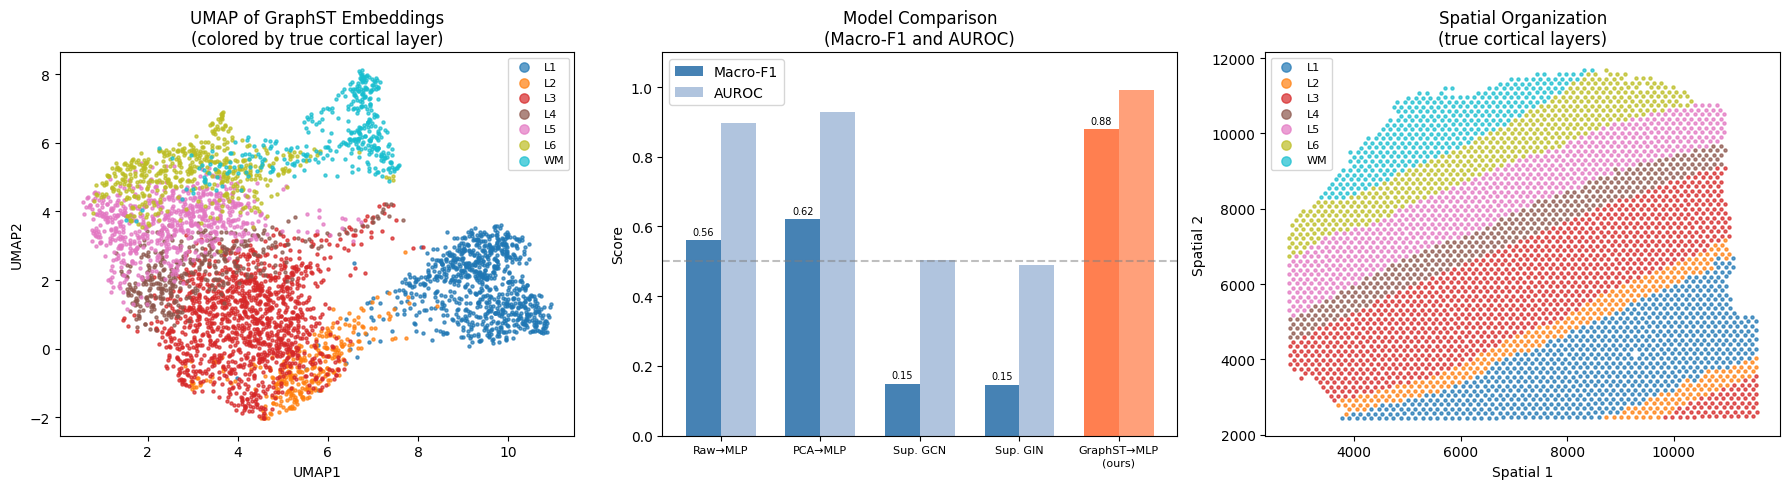

Figure saved!


In [14]:
# Cell 10 - Visualizations for report
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: UMAP of GraphST embeddings colored by true layer ---
reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=42)
embedding_2d = reducer.fit_transform(np.nan_to_num(adata.obsm['emb']))

colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, layer in enumerate(le.classes_):
    mask = adata.obs['label_int'].values == i
    axes[0].scatter(embedding_2d[mask, 0], embedding_2d[mask, 1],
                   c=[colors[i]], label=layer, s=5, alpha=0.7)
axes[0].set_title('UMAP of GraphST Embeddings\n(colored by true cortical layer)')
axes[0].legend(markerscale=3, fontsize=8)
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')

# --- Plot 2: Bar chart of results ---
models = ['Raw→MLP', 'PCA→MLP', 'Sup. GCN', 'Sup. GIN', 'GraphST→MLP\n(ours)']
f1_scores = [raw_f1, pca_f1, gcn_f1, gin_f1, f1_ours]
auroc_scores = [raw_auroc, pca_auroc, gcn_auroc, gin_auroc, auroc_ours]

x = np.arange(len(models))
width = 0.35
bars1 = axes[1].bar(x - width/2, f1_scores, width, label='Macro-F1', 
                     color=['steelblue']*4 + ['coral'])
bars2 = axes[1].bar(x + width/2, auroc_scores, width, label='AUROC',
                     color=['lightsteelblue']*4 + ['lightsalmon'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=8)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Comparison\n(Macro-F1 and AUROC)')
axes[1].legend()
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Add value labels on bars
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

# --- Plot 3: Spatial plot of true layers ---
spatial = adata.obsm['spatial']
for i, layer in enumerate(le.classes_):
    mask = adata.obs['label_int'].values == i
    axes[2].scatter(spatial[mask, 0], spatial[mask, 1],
                   c=[colors[i]], label=layer, s=5, alpha=0.7)
axes[2].set_title('Spatial Organization\n(true cortical layers)')
axes[2].legend(markerscale=3, fontsize=8)
axes[2].set_xlabel('Spatial 1')
axes[2].set_ylabel('Spatial 2')

plt.tight_layout()
plt.savefig('../figures/results_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved!")

In [27]:
# Cell 11 - Novel Contribution: Joint Fine-Tuning Ablation
# Semi-supervised GraphST: combined contrastive + classification loss
# Motivated by Kipf & Welling (2017), You et al. (2020), Rong et al. (2020)

import sys
from tqdm import tqdm
sys.path.insert(0, '../GraphST')

from GraphST.preprocess import (preprocess_adj, preprocess, construct_interaction,
                                 add_contrastive_label, get_feature, permutation, fix_seed)
from GraphST.model import Encoder

# ── Joint Encoder + MLP Classifier ──────────────────────────────────────────

class JointGraphST(nn.Module):
    """
    Novel semi-supervised extension of GraphST.
    
    Combined loss (our contribution):
        L = alpha * recon_loss + beta * contrastive_loss + gamma * classification_loss
    
    When gamma=0: reduces to original GraphST (purely unsupervised)
    When gamma>0: supervision signal guides spatial embeddings toward
                  cortical layer discriminability
                  
    Reference: Kipf & Welling (ICLR 2017) semi-supervised GCN framework
    """
    def __init__(self, dim_input, dim_output, graph_neigh, num_classes, 
                 hidden_dim=256, dropout=0.3):
        super().__init__()
        self.encoder = Encoder(dim_input, dim_output, graph_neigh)
        self.classifier = nn.Sequential(
            nn.Linear(dim_output, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )
    
    def forward(self, features, features_a, adj):
        hidden_feat, emb, ret, ret_a = self.encoder(features, features_a, adj)
        # Use hidden_feat (64-dim latent) not emb (reconstructed input)
        logits = self.classifier(hidden_feat)
        return hidden_feat, emb, ret, ret_a, logits


def run_joint_graphst(adata_input, labels, train_mask, test_mask, 
                       n_classes, gamma, device, 
                       epochs=600, alpha=10, beta=1, random_seed=41):
    """
    Train joint GraphST with given gamma and return test metrics.
    gamma=0 → pure unsupervised (original GraphST)
    gamma>0 → semi-supervised (our contribution)
    """
    fix_seed(random_seed)
    
    # Fresh copy of adata for each run
    adata_run = adata_input.copy()
    
    # Run GraphST preprocessing
    if 'highly_variable' not in adata_run.var.keys():
        preprocess(adata_run)
    if 'adj' not in adata_run.obsm.keys():
        construct_interaction(adata_run)
    if 'label_CSL' not in adata_run.obsm.keys():
        add_contrastive_label(adata_run)
    if 'feat' not in adata_run.obsm.keys():
        get_feature(adata_run)

    features = torch.FloatTensor(adata_run.obsm['feat'].copy()).to(device)
    features_a = torch.FloatTensor(adata_run.obsm['feat_a'].copy()).to(device)
    label_CSL = torch.FloatTensor(adata_run.obsm['label_CSL']).to(device)
    adj_mat = adata_run.obsm['adj']
    graph_neigh = torch.FloatTensor(
        adata_run.obsm['graph_neigh'].copy() + np.eye(adj_mat.shape[0])
    ).to(device)
    adj_mat = preprocess_adj(adj_mat)
    adj_tensor = torch.FloatTensor(adj_mat).to(device)

    dim_input = features.shape[1]
    dim_output = 64

    # Class weights for imbalance
    class_counts = np.bincount(labels[train_mask])
    class_weights = torch.FloatTensor(1.0 / class_counts).to(device)

    # Initialize joint model
    model = JointGraphST(dim_input, dim_output, graph_neigh, n_classes).to(device)
    
    loss_CSL = nn.BCEWithLogitsLoss()
    loss_CE = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0)

    labels_tensor = torch.LongTensor(labels).to(device)
    train_mask_tensor = torch.BoolTensor(train_mask).to(device)

    # Training loop
    for epoch in tqdm(range(epochs), desc=f"gamma={gamma}"):
        model.train()
        features_a = permutation(features)
        hidden, emb, ret, ret_a, logits = model(features, features_a, adj_tensor)

        # Original GraphST losses
        loss_sl_1 = loss_CSL(ret, label_CSL)
        loss_sl_2 = loss_CSL(ret_a, label_CSL)
        loss_feat = F.mse_loss(features, emb)

        # Novel classification loss (only on labeled spots)
        loss_cls = loss_CE(logits[train_mask_tensor], 
                           labels_tensor[train_mask_tensor])

        # Combined loss — key novel contribution
        # gamma=0 → original GraphST, gamma>0 → semi-supervised
        loss = alpha * loss_feat + beta * (loss_sl_1 + loss_sl_2) + gamma * loss_cls

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        features_a_eval = permutation(features)
        _, emb_final, _, _, logits_final = model(features, features_a_eval, adj_tensor)
        
        test_logits = logits_final[test_mask]
        test_probs = F.softmax(test_logits, dim=1).cpu().numpy()
        test_preds = test_logits.argmax(dim=1).cpu().numpy()
        test_true = labels[test_mask]

        # Clustering metrics on full embeddings
        emb_np = np.nan_to_num(emb_final.cpu().numpy())
        kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(emb_np)
        ari = adjusted_rand_score(labels, cluster_labels)
        nmi = normalized_mutual_info_score(labels, cluster_labels)

        # Classification metrics
        macro_f1 = f1_score(test_true, test_preds, average='macro', zero_division=0)
        y_bin = label_binarize(test_true, classes=range(n_classes))
        auroc = roc_auc_score(y_bin, test_probs, multi_class='ovr', average='macro')

    return {
        'gamma': gamma,
        'macro_f1': macro_f1,
        'auroc': auroc,
        'ari': ari,
        'nmi': nmi
    }


# ── Run Ablation ─────────────────────────────────────────────────────────────

# Reload fresh adata (before GraphST modified it)
adata_fresh = sc.read_visium(DATA_PATH, count_file='filtered_feature_bc_matrix.h5',
                              load_images=False)
adata_fresh.var_names_make_unique()
positions_fresh = pd.read_csv(
    os.path.join(DATA_PATH, 'spatial', 'tissue_positions_list.csv'),
    header=None,
    names=['barcode','in_tissue','row','col','pxl_row','pxl_col'],
    index_col=0
)
adata_fresh.obs['array_row'] = positions_fresh.loc[adata_fresh.obs_names, 'row']
adata_fresh.obs['array_col'] = positions_fresh.loc[adata_fresh.obs_names, 'col']
adata_fresh.obsm['spatial'] = positions_fresh.loc[
    adata_fresh.obs_names, ['pxl_col','pxl_row']].values
metadata_fresh = pd.read_csv(os.path.join(DATA_PATH, 'metadata.tsv'), sep='\t', index_col=0)
adata_fresh.obs['layer'] = metadata_fresh.loc[adata_fresh.obs_names, 'layer_guess_reordered_short']
adata_fresh = adata_fresh[adata_fresh.obs['layer'].notna()].copy()
adata_fresh.obs['label_int'] = le.transform(adata_fresh.obs['layer'])

labels_all = adata_fresh.obs['label_int'].values
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Same train/test split as before
n = len(labels_all)
idx = np.arange(n)
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42, 
                                        stratify=labels_all)
train_mask_ab = np.zeros(n, dtype=bool)
test_mask_ab = np.zeros(n, dtype=bool)
train_mask_ab[train_idx] = True
test_mask_ab[test_idx] = True

# Gamma values to ablate
# gamma=0: original GraphST (unsupervised pretraining only)
# gamma>0: our semi-supervised extension
gammas = [0, 0.1, 0.5, 1.0, 5.0]
ablation_results = []

print("Running gamma ablation study...")
print("(Each run trains for 600 epochs — ~5 min per run on CPU)\n")

for gamma in gammas:
    print(f"\n--- gamma = {gamma} ---")
    result = run_joint_graphst(
        adata_fresh, labels_all, train_mask_ab, test_mask_ab,
        n_classes=n_classes, gamma=gamma, device=device
    )
    ablation_results.append(result)
    print(f"Macro-F1: {result['macro_f1']:.4f} | AUROC: {result['auroc']:.4f} | "
          f"ARI: {result['ari']:.4f} | NMI: {result['nmi']:.4f}")

# ── Final Results Table ──────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Model':<40} {'Macro-F1':>8} {'AUROC':>8} {'ARI':>7} {'NMI':>7}")
print("-"*70)

# Prior baselines
print(f"{'Raw counts → MLP':<40} {raw_f1:>8.4f} {raw_auroc:>8.4f} {'—':>7} {'—':>7}")
print(f"{'PCA → MLP':<40} {pca_f1:>8.4f} {pca_auroc:>8.4f} {'—':>7} {'—':>7}")
print(f"{'Supervised GCN from scratch':<40} {gcn_f1:>8.4f} {gcn_auroc:>8.4f} {'—':>7} {'—':>7}")
print(f"{'Supervised GIN from scratch':<40} {gin_f1:>8.4f} {gin_auroc:>8.4f} {'—':>7} {'—':>7}")
print(f"{'GraphST → MLP (frozen, ours)':<40} {f1_ours:>8.4f} {auroc_ours:>8.4f} {ari:>7.4f} {nmi:>7.4f}")
print("-"*70)

# Ablation results
for r in ablation_results:
    label = f"Joint GraphST (gamma={r['gamma']})"
    if r['gamma'] == 0:
        label += " [baseline]"
    print(f"{label:<40} {r['macro_f1']:>8.4f} {r['auroc']:>8.4f} "
          f"{r['ari']:>7.4f} {r['nmi']:>7.4f}")

/var/folders/vg/t0bx9bsx13q7_9vhghhczmvr0000gp/T/ipykernel_9282/2846609944.py:159: FutureWarning: Use `squidpy.read.visium` instead.
  adata_fresh = sc.read_visium(DATA_PATH, count_file='filtered_feature_bc_matrix.h5',
/Users/student/miniconda3/envs/GraphST310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/student/miniconda3/envs/GraphST310/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Running gamma ablation study...
(Each run trains for 600 epochs — ~5 min per run on CPU)


--- gamma = 0 ---


gamma=0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [03:53<00:00,  2.57it/s]


Macro-F1: 0.1055 | AUROC: 0.4908 | ARI: 0.4162 | NMI: 0.5322

--- gamma = 0.1 ---


gamma=0.1: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [04:14<00:00,  2.36it/s]


...

Macro-F1: 0.8504 | AUROC: 0.9776 | ARI: 0.4549 | NMI: 0.5641

--- gamma = 1.0 ---


gamma=1.0: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [04:39<00:00,  2.14it/s]


Macro-F1: 0.8727 | AUROC: 0.9822 | ARI: 0.4558 | NMI: 0.5664

--- gamma = 5.0 ---


gamma=5.0: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [04:42<00:00,  2.12it/s]


Macro-F1: 0.9100 | AUROC: 0.9885 | ARI: 0.4542 | NMI: 0.5657

Model                                    Macro-F1    AUROC     ARI     NMI
----------------------------------------------------------------------
Raw counts → MLP                           0.5606   0.8957       —       —
PCA → MLP                                  0.6211   0.9270       —       —
Supervised GCN from scratch                0.1486   0.5041       —       —
Supervised GIN from scratch                0.1462   0.4908       —       —
GraphST → MLP (frozen, ours)               0.8784   0.9905  0.4162  0.5322
----------------------------------------------------------------------
Joint GraphST (gamma=0) [baseline]         0.1055   0.4908  0.4162  0.5322
Joint GraphST (gamma=0.1)                  0.8174   0.9697  0.3900  0.5316
Joint GraphST (gamma=0.5)                  0.8504   0.9776  0.4549  0.5641
Joint GraphST (gamma=1.0)                  0.8727   0.9822  0.4558  0.5664
Joint GraphST (gamma=5.0)                  0.9

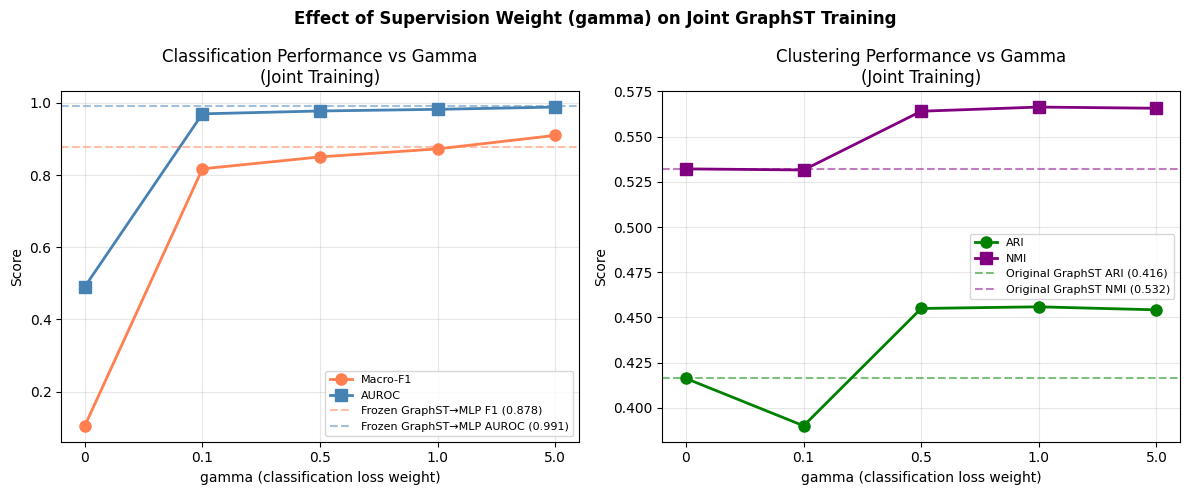

Figure saved!
[0, 0.1, 0.5, 1.0, 5.0]
[0.10550640417033616, 0.8173587285011108, 0.8503584461054938, 0.8726507399480771, 0.909965327358874]
[0.49080536542185677, 0.9696805753111567, 0.9776092125318004, 0.9821938688713773, 0.9884566223210868]
[0.4161713088973593, 0.3899851957383703, 0.4549176450254363, 0.4558303295357902, 0.45415835212940775]
[0.5321667433537749, 0.5315659557767937, 0.5640908244353805, 0.5663813300530606, 0.5657242472564791]


In [28]:
# Cell 12 - Visualize gamma ablation results (fixed)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gammas_plot = [r['gamma'] for r in ablation_results]
f1_plot     = [r['macro_f1'] for r in ablation_results]
auroc_plot  = [r['auroc'] for r in ablation_results]
ari_plot    = [r['ari'] for r in ablation_results]
nmi_plot    = [r['nmi'] for r in ablation_results]

x_ticks = list(range(len(gammas_plot)))  # 0,1,2,3,4 as positions
x_labels = [str(g) for g in gammas_plot]  # '0','0.1','0.5','1.0','5.0'

# --- Plot 1: Classification metrics ---
axes[0].plot(x_ticks, f1_plot, 'o-', color='coral', linewidth=2,
             markersize=8, label='Macro-F1')
axes[0].plot(x_ticks, auroc_plot, 's-', color='steelblue', linewidth=2,
             markersize=8, label='AUROC')
axes[0].axhline(y=f1_ours, color='coral', linestyle='--', alpha=0.5,
                label=f'Frozen GraphST→MLP F1 ({f1_ours:.3f})')
axes[0].axhline(y=auroc_ours, color='steelblue', linestyle='--', alpha=0.5,
                label=f'Frozen GraphST→MLP AUROC ({auroc_ours:.3f})')
axes[0].set_xticks(x_ticks)
axes[0].set_xticklabels(x_labels)
axes[0].set_xlabel('gamma (classification loss weight)')
axes[0].set_ylabel('Score')
axes[0].set_title('Classification Performance vs Gamma\n(Joint Training)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# --- Plot 2: Clustering metrics ---
axes[1].plot(x_ticks, ari_plot, 'o-', color='green', linewidth=2,
             markersize=8, label='ARI')
axes[1].plot(x_ticks, nmi_plot, 's-', color='purple', linewidth=2,
             markersize=8, label='NMI')
axes[1].axhline(y=ari, color='green', linestyle='--', alpha=0.5,
                label=f'Original GraphST ARI ({ari:.3f})')
axes[1].axhline(y=nmi, color='purple', linestyle='--', alpha=0.5,
                label=f'Original GraphST NMI ({nmi:.3f})')
axes[1].set_xticks(x_ticks)
axes[1].set_xticklabels(x_labels)
axes[1].set_xlabel('gamma (classification loss weight)')
axes[1].set_ylabel('Score')
axes[1].set_title('Clustering Performance vs Gamma\n(Joint Training)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Effect of Supervision Weight (gamma) on Joint GraphST Training',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/gamma_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved!")
print(gammas_plot)
print(f1_plot)
print(auroc_plot)
print(ari_plot)
print(nmi_plot)


In [29]:
print(gammas_plot)
print(f1_plot)
print(auroc_plot)
print(ari_plot)
print(nmi_plot)


[0, 0.1, 0.5, 1.0, 5.0]
[0.10550640417033616, 0.8173587285011108, 0.8503584461054938, 0.8726507399480771, 0.909965327358874]
[0.49080536542185677, 0.9696805753111567, 0.9776092125318004, 0.9821938688713773, 0.9884566223210868]
[0.4161713088973593, 0.3899851957383703, 0.4549176450254363, 0.4558303295357902, 0.45415835212940775]
[0.5321667433537749, 0.5315659557767937, 0.5640908244353805, 0.5663813300530606, 0.5657242472564791]


Joint γ=5.0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [01:52<00:00,  2.67it/s]


Computing UMAPs...
UMAP 1: PCA features...


/Users/student/miniconda3/envs/GraphST310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2: GraphST embeddings...
UMAP 3: Joint GraphST embeddings...


FileNotFoundError: [Errno 2] No such file or directory: '../figures/umap_comparison.png'

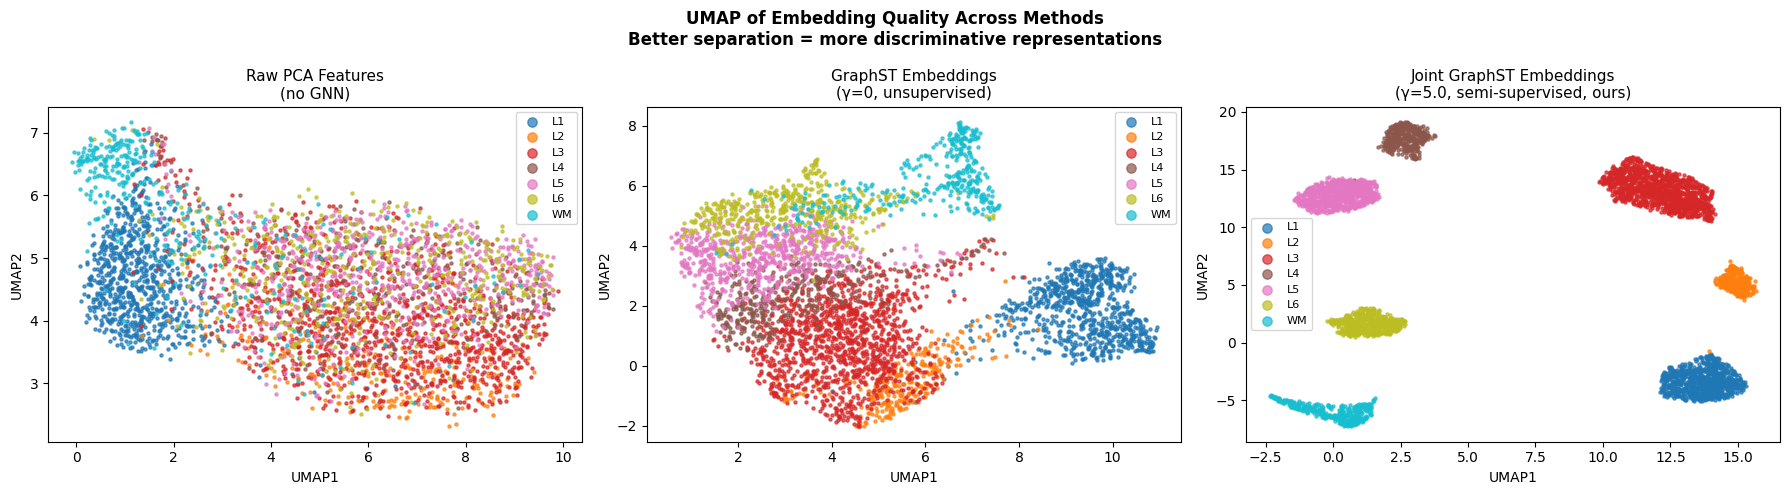

In [33]:
# Cell 13 - UMAP comparison: Raw PCA vs GraphST vs Joint GraphST
import umap

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Get embeddings for each method
# 1. Raw PCA features (already computed)
X_pca_plot = X_pca  # from Cell 7

# 2. Frozen GraphST embeddings (already computed)
X_graphst = np.nan_to_num(adata.obsm['emb'])

# 3. Joint GraphST embeddings (gamma=5.0, best model)
# Re-extract from our joint model results
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reload fresh adata for joint model
adata_joint = adata.copy()
adata_joint.obs['label_int'] = le.transform(adata_joint.obs['layer'])
labels_joint = adata_joint.obs['label_int'].values

# Re-run joint GraphST with gamma=5.0 to get embeddings
from GraphST.preprocess import (preprocess_adj, preprocess, construct_interaction,
                                 add_contrastive_label, get_feature, permutation, fix_seed)
from GraphST.model import Encoder

def get_joint_embeddings(adata_input, labels, gamma, n_classes, device, epochs=300):
    fix_seed(41)
    adata_run = adata_input.copy()
    if 'highly_variable' not in adata_run.var.keys():
        preprocess(adata_run)
    if 'adj' not in adata_run.obsm.keys():
        construct_interaction(adata_run)
    if 'label_CSL' not in adata_run.obsm.keys():
        add_contrastive_label(adata_run)
    if 'feat' not in adata_run.obsm.keys():
        get_feature(adata_run)

    features = torch.FloatTensor(adata_run.obsm['feat'].copy()).to(device)
    label_CSL = torch.FloatTensor(adata_run.obsm['label_CSL']).to(device)
    adj_mat = adata_run.obsm['adj']
    graph_neigh = torch.FloatTensor(
        adata_run.obsm['graph_neigh'].copy() + np.eye(adj_mat.shape[0])
    ).to(device)
    adj_tensor = torch.FloatTensor(preprocess_adj(adj_mat)).to(device)

    class_counts = np.bincount(labels, minlength=n_classes)
    class_counts = np.where(class_counts == 0, 1, class_counts)
    class_weights = torch.FloatTensor(1.0 / class_counts).to(device)

    # Reuse JointGraphST from Cell 11
    model = JointGraphST(features.shape[1], 64, graph_neigh, n_classes).to(device)
    loss_CSL = nn.BCEWithLogitsLoss()
    loss_CE = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    labels_tensor = torch.LongTensor(labels).to(device)
    train_mask = torch.ones(len(labels), dtype=torch.bool).to(device)

    for epoch in tqdm(range(epochs), desc=f"Joint γ={gamma}"):
        model.train()
        features_a = permutation(features)
        hidden, emb, ret, ret_a, logits = model(features, features_a, adj_tensor)
        loss_sl_1 = loss_CSL(ret, label_CSL)
        loss_sl_2 = loss_CSL(ret_a, label_CSL)
        loss_feat = F.mse_loss(features, emb)
        loss_cls = loss_CE(logits[train_mask], labels_tensor[train_mask])
        loss = 10 * loss_feat + 1 * (loss_sl_1 + loss_sl_2) + gamma * loss_cls
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        features_a = permutation(features)
        hidden, _, _, _, _ = model(features, features_a, adj_tensor)
        return np.nan_to_num(hidden.cpu().numpy())

# Get joint embeddings (use 300 epochs for speed)
X_joint = get_joint_embeddings(adata_joint, labels_joint, gamma=5.0, 
                                n_classes=n_classes, device=device, epochs=300)

# Compute UMAPs for all three
print("Computing UMAPs...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=42)

print("UMAP 1: PCA features...")
umap_pca = reducer.fit_transform(X_pca[:len(true_labels)])

print("UMAP 2: GraphST embeddings...")
umap_graphst = reducer.fit_transform(X_graphst)

print("UMAP 3: Joint GraphST embeddings...")
umap_joint = reducer.fit_transform(X_joint)

# Plot
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
titles = ['Raw PCA Features\n(no GNN)', 
          'GraphST Embeddings\n(γ=0, unsupervised)',
          'Joint GraphST Embeddings\n(γ=5.0, semi-supervised, ours)']

for ax, umap_emb, title in zip(axes, [umap_pca, umap_graphst, umap_joint], titles):
    for i, layer in enumerate(le.classes_):
        mask = true_labels == i
        ax.scatter(umap_emb[mask, 0], umap_emb[mask, 1],
                  c=[colors[i]], label=layer, s=5, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.legend(markerscale=3, fontsize=8)
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')

plt.suptitle('UMAP of Embedding Quality Across Methods\n'
             'Better separation = more discriminative representations',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/umap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")